In [ ]:
from pathlib import Path

PLAYER_NAME = "Cole Young"
MLBAM_ID = 702284             # Set to None to look up the player from PLAYER_NAME

START_DATE = "2026-3-15"
END_DATE = "2026-09-02"
REGULAR_SEASON_ONLY = True

DATA_FILE = None
DOWNLOAD_ALL_PITCHES = True
DOWNLOAD_STEP_DAYS = 5
MAX_DOWNLOAD_ATTEMPTS = 3
FORCE_DOWNLOAD = False        # True rebuilds the download and its chunk caches

OUTPUT_DIR = Path("hitter_reports")
REPORT_THEME = "blue"       # maroon, navy, blue, green, purple, orange, or charcoal
MIN_SPLIT_PITCHES = 20
MIN_SPLIT_BIP = 5
REPORT_DPI = 320

In [ ]:
import re
import time
import warnings
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch

warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
pd.set_option("display.max_columns", 50)

OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = OUTPUT_DIR / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

REPORT_THEMES = {
    "maroon": ("#7A0019", "#C4CED4"),
    "navy": ("#0B1F3A", "#B8C5D6"),
    "blue": ("#1F4E79", "#BDD7EE"),
    "green": ("#1F5E46", "#C6E0D5"),
    "purple": ("#5B3A70", "#D7C9E3"),
    "orange": ("#A64B00", "#F2D1B3"),
    "charcoal": ("#30343B", "#D0D3D6"),
}
theme_key = str(REPORT_THEME).strip().lower()
if theme_key not in REPORT_THEMES:
    valid_themes = ", ".join(REPORT_THEMES)
    raise ValueError(f"Unknown REPORT_THEME '{REPORT_THEME}'. Choose: {valid_themes}")
PRIMARY_COLOR, SECONDARY_COLOR = REPORT_THEMES[theme_key]

SWING_EVENTS = {
    "swinging_strike", "swinging_strike_blocked", "foul", "foul_tip",
    "hit_into_play", "foul_bunt", "missed_bunt"
}
CONTACT_EVENTS = {"foul", "foul_tip", "hit_into_play", "foul_bunt"}
WHIFF_EVENTS = {"swinging_strike", "swinging_strike_blocked", "missed_bunt"}

NON_AB_EVENTS = {
    "walk", "intent_walk", "hit_by_pitch", "catcher_interf",
    "sac_fly", "sac_bunt"
}
HIT_EVENTS = {"single", "double", "triple", "home_run"}

PITCH_FAMILIES = {
    "4-Seam Fastball": "Fastballs", "Sinker": "Fastballs",
    "2-Seam Fastball": "Fastballs", "Cutter": "Fastballs",
    "Slider": "Breaking", "Sweeper": "Breaking", "Curveball": "Breaking",
    "Knuckle Curve": "Breaking", "Slow Curve": "Breaking", "Slurve": "Breaking",
    "Changeup": "Offspeed", "Split-Finger": "Offspeed", "Forkball": "Offspeed",
    "Screwball": "Offspeed", "Knuckle Ball": "Other", "Eephus": "Other"
}
FAMILY_ORDER = ["Fastballs", "Breaking", "Offspeed", "Other"]
COUNT_ORDER = ["Ahead", "Even", "Behind"]
VERTICAL_ORDER = ["High", "Middle", "Low"]
HORIZONTAL_ORDER = ["Away", "Middle", "Inside"]


def slugify(value):
    return re.sub(r"[^a-z0-9]+", "_", str(value).lower()).strip("_")


def safe_divide(numerator, denominator):
    return numerator / denominator if denominator else np.nan


def load_local_data(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"DATA_FILE does not exist: {path}")
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path, low_memory=False)
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    if suffix in {".parquet", ".pq"}:
        return pd.read_parquet(path)
    raise ValueError("DATA_FILE must be a CSV, XLSX/XLS, or Parquet file.")


def resolve_mlbam_id(player_name, configured_id=None):
    if configured_id is not None:
        return int(configured_id)

    parts = str(player_name).strip().split()
    if len(parts) < 2:
        raise ValueError("Enter PLAYER_NAME as 'First Last' or provide MLBAM_ID.")

    try:
        from pybaseball import playerid_lookup
    except ImportError as exc:
        raise ImportError(
            "Automatic player lookup requires pybaseball. Install it or provide MLBAM_ID."
        ) from exc

    first_name = " ".join(parts[:-1])
    last_name = parts[-1]
    candidates = playerid_lookup(last_name, first_name, fuzzy=True)
    candidates = candidates.loc[candidates["key_mlbam"].notna()].copy()
    if candidates.empty:
        raise ValueError(f"No MLBAM ID found for {player_name}. Provide MLBAM_ID manually.")

    exact = candidates[
        candidates["name_first"].fillna("").str.casefold().eq(first_name.casefold())
        & candidates["name_last"].fillna("").str.casefold().eq(last_name.casefold())
    ]
    if not exact.empty:
        candidates = exact

    sort_columns = [c for c in ["mlb_played_last", "mlb_played_first"] if c in candidates]
    if sort_columns:
        candidates = candidates.sort_values(sort_columns, ascending=False)

    selected = candidates.iloc[0]
    print(
        f"Resolved {player_name} to MLBAM ID {int(selected['key_mlbam'])}. "
        "Set MLBAM_ID manually if this is not the intended player."
    )
    return int(selected["key_mlbam"])


def download_all_statcast(start_date, end_date):
    combined_path = CACHE_DIR / f"all_statcast_{start_date}_{end_date}.pkl"
    chunk_dir = CACHE_DIR / "all_statcast_chunks"
    chunk_dir.mkdir(parents=True, exist_ok=True)

    if combined_path.exists() and not FORCE_DOWNLOAD:
        print(f"Loading combined full-range cache: {combined_path}")
        return pd.read_pickle(combined_path)

    try:
        from pybaseball import cache, statcast
    except ImportError as exc:
        raise ImportError(
            "Downloading Statcast data requires pybaseball. "
            "Run `pip install pybaseball` or provide DATA_FILE."
        ) from exc

    cache.enable()
    start = datetime.strptime(start_date, "%Y-%m-%d")
    end = datetime.strptime(end_date, "%Y-%m-%d")
    if end < start:
        raise ValueError("END_DATE must be on or after START_DATE.")

    chunks = []
    current = start
    while current <= end:
        chunk_end = min(current + timedelta(days=DOWNLOAD_STEP_DAYS - 1), end)
        chunk_start_text = current.strftime("%Y-%m-%d")
        chunk_end_text = chunk_end.strftime("%Y-%m-%d")
        chunk_path = chunk_dir / f"statcast_{chunk_start_text}_{chunk_end_text}.pkl"

        if chunk_path.exists() and not FORCE_DOWNLOAD:
            print(f"Loading cached chunk: {chunk_start_text} to {chunk_end_text}")
            chunk = pd.read_pickle(chunk_path)
        else:
            chunk = None
            for attempt in range(1, MAX_DOWNLOAD_ATTEMPTS + 1):
                try:
                    print(
                        f"Downloading all pitches: {chunk_start_text} to {chunk_end_text} "
                        f"(attempt {attempt}/{MAX_DOWNLOAD_ATTEMPTS})"
                    )
                    chunk = statcast(start_dt=chunk_start_text, end_dt=chunk_end_text)
                    if chunk is None:
                        chunk = pd.DataFrame()
                    chunk.to_pickle(chunk_path)
                    break
                except Exception as exc:
                    if attempt == MAX_DOWNLOAD_ATTEMPTS:
                        raise RuntimeError(
                            f"Download failed for {chunk_start_text} to {chunk_end_text}. "
                            "Completed earlier chunks remain cached; rerun to resume."
                        ) from exc
                    wait_seconds = 3 * attempt
                    print(f"Chunk failed: {exc}. Retrying in {wait_seconds} seconds...")
                    time.sleep(wait_seconds)

        if chunk is not None and not chunk.empty:
            chunks.append(chunk)
        current = chunk_end + timedelta(days=1)

    if not chunks:
        raise ValueError("No Statcast pitches were returned for the selected date range.")

    data = pd.concat(chunks, ignore_index=True)
    dedupe_columns = [
        column for column in ["game_pk", "at_bat_number", "pitch_number"]
        if column in data.columns
    ]
    if len(dedupe_columns) == 3:
        before = len(data)
        data = data.drop_duplicates(dedupe_columns).reset_index(drop=True)
        removed = before - len(data)
        if removed:
            print(f"Removed {removed:,} duplicate pitch rows.")

    data.to_pickle(combined_path)
    print(f"Saved combined full-range cache: {combined_path}")
    return data


def download_selected_hitter(start_date, end_date, player_id):
    cache_path = CACHE_DIR / (
        f"player_{player_id}_{start_date}_{end_date}.pkl"
    )
    if cache_path.exists() and not FORCE_DOWNLOAD:
        print(f"Loading cached player data: {cache_path}")
        return pd.read_pickle(cache_path)

    try:
        from pybaseball import cache, statcast_batter
    except ImportError as exc:
        raise ImportError(
            "Downloading Statcast data requires pybaseball. "
            "Run `pip install pybaseball` or provide DATA_FILE."
        ) from exc
    cache.enable()
    print(f"Downloading Statcast data for {PLAYER_NAME} ({player_id})...")
    data = statcast_batter(start_date, end_date, player_id)
    data.to_pickle(cache_path)
    print(f"Cached player download: {cache_path}")
    return data


def load_statcast_universe():
    if DATA_FILE is not None:
        print(f"Loading local Statcast file: {DATA_FILE}")
        return load_local_data(DATA_FILE)
    if DOWNLOAD_ALL_PITCHES:
        return download_all_statcast(START_DATE, END_DATE)
    player_id = resolve_mlbam_id(PLAYER_NAME, MLBAM_ID)
    return download_selected_hitter(START_DATE, END_DATE, player_id)


def select_player(data):
    if data is None or data.empty:
        raise ValueError("The full Statcast dataset is empty.")

    player_id = MLBAM_ID
    if player_id is None and "batter" in data.columns:
        unique_ids = pd.to_numeric(data["batter"], errors="coerce").dropna().astype(int).unique()
        if len(unique_ids) == 1:
            player_id = int(unique_ids[0])
    if player_id is None:
        player_id = resolve_mlbam_id(PLAYER_NAME, player_id)

    if "batter" in data.columns:
        batter_ids = pd.to_numeric(data["batter"], errors="coerce")
        selected = data.loc[batter_ids.eq(int(player_id))].copy()
    else:
        print("Dataset has no 'batter' column; treating every row as the selected player.")
        selected = data.copy()

    if "game_date" in selected.columns:
        selected["game_date"] = pd.to_datetime(selected["game_date"], errors="coerce")
        selected = selected.loc[
            selected["game_date"].between(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE))
        ].copy()

    if REGULAR_SEASON_ONLY and "game_type" in selected.columns:
        selected = selected.loc[selected["game_type"].eq("R")].copy()

    if selected.empty:
        raise ValueError(
            f"No pitches were found for {PLAYER_NAME} ({player_id}) after filtering. "
            "Check the MLBAM ID and date range."
        )
    return selected.reset_index(drop=True), int(player_id)


In [ ]:
all_statcast_df = load_statcast_universe()
print(f"Full dataset available: {len(all_statcast_df):,} pitch rows")

raw_df, RESOLVED_MLBAM_ID = select_player(all_statcast_df)
print(
    f"Loaded {len(raw_df):,} pitches for {PLAYER_NAME} | "
    f"{START_DATE} through {END_DATE}"
)
display(raw_df.head(3))


Loading combined full-range cache: hitter_reports\cache\all_statcast_2026-3-15_2026-09-02.pkl
Full dataset available: 657,738 pitch rows
Loaded 2,142 pitches for Cole Young | 2026-3-15 through 2026-09-02


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,spin_dir,spin_rate_deprecated,break_angle_deprecated,break_length_deprecated,zone,des,game_type,stand,p_throws,home_team,away_team,type,hit_location,bb_type,balls,...,delta_pitcher_run_exp,hyper_speed,home_score_diff,bat_score_diff,home_win_exp,bat_win_exp,age_pit_legacy,age_bat_legacy,age_pit,age_bat,n_thruorder_pitcher,n_priorpa_thisgame_player_at_bat,pitcher_days_since_prev_game,batter_days_since_prev_game,pitcher_days_until_next_game,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,ST,2026-03-29,84.9,-2.09,5.84,"Holderman, Colin",702284,670059,field_out,hit_into_play,<NA>,<NA>,<NA>,<NA>,8,"Cole Young grounds out, first baseman Kyle Man...",R,L,R,SEA,CLE,X,3,ground_ball,1,...,0.182,95.4,7,7,0.996,0.996,30,22,31,23,1,3,2,1,28,1,2.84,-0.9,0.9,28.5,6.769459,-6.636816,24.992312,31.575778,39.206869
1,ST,2026-03-29,85.0,-2.19,5.71,"Holderman, Colin",702284,670059,NaN,ball,<NA>,<NA>,<NA>,<NA>,13,NaN,R,L,R,SEA,CLE,B,<NA>,NaN,0,...,-0.019,<NA>,7,7,0.996,0.996,30,22,31,23,1,3,2,1,28,1,2.61,-0.75,0.75,29.8,<NA>,<NA>,<NA>,<NA>,<NA>
2,ST,2026-03-29,85.3,-2.17,5.74,"Holderman, Colin",702284,670059,NaN,called_strike,<NA>,<NA>,<NA>,<NA>,5,NaN,R,L,R,SEA,CLE,S,<NA>,NaN,0,...,0.058,<NA>,7,7,0.996,0.996,30,22,31,23,1,3,2,1,28,1,2.85,-0.55,0.55,28.6,<NA>,<NA>,<NA>,<NA>,<NA>


In [ ]:
OPTIONAL_COLUMNS = [
    "batter", "game_date", "game_type", "description", "events", "type",
    "pitch_name", "p_throws", "stand", "balls", "strikes", "zone",
    "plate_x", "plate_z", "sz_top", "sz_bot", "launch_speed", "launch_angle",
    "launch_speed_angle", "estimated_ba_using_speedangle",
    "estimated_slg_using_speedangle", "estimated_woba_using_speedangle",
    "bb_type", "hc_x", "hc_y", "bat_speed", "swing_length", "attack_angle",
    "attack_direction", "swing_path_tilt"
]
df = raw_df.copy()
for column in OPTIONAL_COLUMNS:
    if column not in df.columns:
        df[column] = np.nan

NUMERIC_COLUMNS = [
    "batter", "balls", "strikes", "zone", "plate_x", "plate_z", "sz_top",
    "sz_bot", "launch_speed", "launch_angle", "launch_speed_angle",
    "estimated_ba_using_speedangle", "estimated_slg_using_speedangle",
    "estimated_woba_using_speedangle", "hc_x", "hc_y", "bat_speed",
    "swing_length", "attack_angle", "attack_direction", "swing_path_tilt"
]
for column in NUMERIC_COLUMNS:
    df[column] = (
        pd.to_numeric(df[column], errors="coerce")
        .astype("float64")
    )

df["description"] = df["description"].fillna("").astype(str)
df["events"] = df["events"].where(df["events"].notna(), np.nan)
df["pitch_name"] = df["pitch_name"].fillna("Unknown").astype(str)
df["p_throws"] = df["p_throws"].fillna("Unknown").astype(str)
df["stand"] = df["stand"].fillna("Unknown").astype(str)

df["swing"] = df["description"].isin(SWING_EVENTS)
df["contact"] = df["description"].isin(CONTACT_EVENTS) | df["type"].eq("X")
df["whiff"] = df["description"].isin(WHIFF_EVENTS)
df["called_strike"] = df["description"].eq("called_strike")
df["in_zone"] = df["zone"].between(1, 9)


def count_category(row):
    balls, strikes = row["balls"], row["strikes"]
    if pd.isna(balls) or pd.isna(strikes):
        return "Unknown"
    balls, strikes = int(balls), int(strikes)
    if (balls, strikes) in {(1, 0), (2, 0), (3, 0), (2, 1), (3, 1)}:
        return "Ahead"
    if (balls, strikes) in {(0, 1), (0, 2), (1, 2)}:
        return "Behind"
    if (balls, strikes) in {(0, 0), (1, 1), (2, 2), (3, 2)}:
        return "Even"
    return "Unknown"


df["count_group"] = df.apply(count_category, axis=1)
df["pitch_family"] = df["pitch_name"].map(PITCH_FAMILIES).fillna("Other")

df["plate_x_hitter"] = np.where(
    df["stand"].eq("R"), -df["plate_x"],
    np.where(df["stand"].eq("L"), df["plate_x"], np.nan)
)
zone_height = (df["sz_top"] - df["sz_bot"]).replace(0, np.nan)
df["plate_z_normalized"] = (df["plate_z"] - df["sz_bot"]) / zone_height

horizontal_away = (
    df["plate_x_hitter"]
    .lt(-0.28)
    .fillna(False)
    .to_numpy(dtype=bool)
)

horizontal_inside = (
    df["plate_x_hitter"]
    .gt(0.28)
    .fillna(False)
    .to_numpy(dtype=bool)
)

vertical_low = (
    df["plate_z_normalized"]
    .lt(1 / 3)
    .fillna(False)
    .to_numpy(dtype=bool)
)

vertical_high = (
    df["plate_z_normalized"]
    .gt(2 / 3)
    .fillna(False)
    .to_numpy(dtype=bool)
)

df["horizontal_zone"] = np.select(
    [horizontal_away, horizontal_inside],
    ["Away", "Inside"],
    default="Middle"
)

df["vertical_zone"] = np.select(
    [vertical_low, vertical_high],
    ["Low", "High"],
    default="Middle"
)

missing_location = (
    df[["plate_x_hitter", "plate_z_normalized"]]
    .isna()
    .any(axis=1)
)

df.loc[
    missing_location,
    ["horizontal_zone", "vertical_zone"]
] = "Unknown"

df["location_zone"] = (
    df["vertical_zone"].astype(str)
    + "-"
    + df["horizontal_zone"].astype(str)
)

df["is_bip"] = (
    (df["description"].eq("hit_into_play") | df["type"].eq("X"))
    & df["launch_speed"].notna() & df["launch_angle"].notna()
)

def manual_barrel(ev, la):
    if pd.isna(ev) or pd.isna(la) or ev < 98:
        return False
    lower = max(8, 26 - (ev - 98))
    upper = min(50, 30 + 2 * (ev - 98))
    return lower <= la <= upper


if df["launch_speed_angle"].notna().any():
    df["barrel"] = df["launch_speed_angle"].eq(6) & df["is_bip"]
else:
    df["barrel"] = [
        manual_barrel(ev, la) and is_bip
        for ev, la, is_bip in zip(df["launch_speed"], df["launch_angle"], df["is_bip"])
    ]
df["hard_hit"] = df["is_bip"] & df["launch_speed"].ge(95)

df["spray_direction"] = pd.Series(pd.NA, index=df.index, dtype="object")
spray_valid = df[["hc_x", "hc_y"]].notna().all(axis=1) & df["is_bip"]
x_field = df.loc[spray_valid, "hc_x"] - 125
y_field = (df.loc[spray_valid, "hc_y"] - 200) * -1
spray_angle = ((np.arctan2(y_field, x_field) / np.pi * 180) - 90) * -1
spray = pd.Series("Center", index=spray_angle.index, dtype="object")
spray.loc[df.loc[spray_valid, "stand"].eq("R") & spray_angle.lt(-17)] = "Pull"
spray.loc[df.loc[spray_valid, "stand"].eq("R") & spray_angle.gt(17)] = "Oppo"
spray.loc[df.loc[spray_valid, "stand"].eq("L") & spray_angle.gt(17)] = "Pull"
spray.loc[df.loc[spray_valid, "stand"].eq("L") & spray_angle.lt(-17)] = "Oppo"
df.loc[spray_valid, "spray_direction"] = spray

print(
    f"Prepared {len(df):,} pitches, {int(df['swing'].sum()):,} swings, "
    f"and {int(df['is_bip'].sum()):,} tracked balls in play."
)

Prepared 2,142 pitches, 1,031 swings, and 417 tracked balls in play.


In [ ]:
def compute_summary(data):
    data = data.copy()
    pitches = len(data)
    swings = int(data["swing"].sum())
    contacts = int((data["swing"] & data["contact"]).sum())
    whiffs = int((data["swing"] & data["whiff"]).sum())
    in_zone = data["in_zone"]
    z_swings = int((data["swing"] & in_zone).sum())
    z_contacts = int((data["swing"] & data["contact"] & in_zone).sum())
    out_zone = ~in_zone
    o_swings = int((data["swing"] & out_zone).sum())

    terminal = data.loc[data["events"].notna()].copy()
    at_bats = terminal.loc[~terminal["events"].isin(NON_AB_EVENTS)].copy()
    bip = data.loc[data["is_bip"]].copy()
    air = bip.loc[bip["bb_type"].isin(["line_drive", "fly_ball"])]
    tracked_swings = data.loc[data["swing"]].copy()
    valid_bat_speed = tracked_swings.loc[tracked_swings["bat_speed"].notna(), "bat_speed"]

    xba_values = at_bats["estimated_ba_using_speedangle"].fillna(0)
    xslg_values = at_bats["estimated_slg_using_speedangle"].fillna(0)
    xwobacon_values = bip["estimated_woba_using_speedangle"].dropna()

    bb = int(terminal["events"].isin(["walk", "intent_walk"]).sum())
    hbp = int(terminal["events"].eq("hit_by_pitch").sum())
    sf = int(terminal["events"].eq("sac_fly").sum())
    strikeouts = int(terminal["events"].isin(["strikeout", "strikeout_double_play"]).sum())
    hits = int(at_bats["events"].isin(HIT_EVENTS).sum())
    total_bases = (
        at_bats["events"].eq("single").sum()
        + 2 * at_bats["events"].eq("double").sum()
        + 3 * at_bats["events"].eq("triple").sum()
        + 4 * at_bats["events"].eq("home_run").sum()
    )
    ab = len(at_bats)
    pa = len(terminal)
    obp_denominator = ab + bb + hbp + sf

    return pd.Series({
        "Pitches": pitches,
        "PA": pa,
        "AB": ab,
        "BIP": len(bip),
        "Swings": swings,
        "AVG": safe_divide(hits, ab),
        "OBP": safe_divide(hits + bb + hbp, obp_denominator),
        "SLG": safe_divide(total_bases, ab),
        "BB%": 100 * safe_divide(bb, pa),
        "K%": 100 * safe_divide(strikeouts, pa),
        "Swing%": 100 * safe_divide(swings, pitches),
        "Contact%": 100 * safe_divide(contacts, swings),
        "Whiff%": 100 * safe_divide(whiffs, swings),
        "Z-Contact%": 100 * safe_divide(z_contacts, z_swings),
        "Chase%": 100 * safe_divide(o_swings, int(out_zone.sum())),
        "CSW%": 100 * safe_divide(int((data["called_strike"] | data["whiff"]).sum()), pitches),
        "Bat-Tracked Swings": len(valid_bat_speed),
        "Bat Speed": valid_bat_speed.mean(),
        "Fast Swing%": 100 * valid_bat_speed.ge(75).mean() if len(valid_bat_speed) else np.nan,
        "Swing-Length Swings": int(tracked_swings["swing_length"].notna().sum()),
        "Swing Length": tracked_swings["swing_length"].mean(),
        "Attack Angle": tracked_swings["attack_angle"].mean(),
        "Attack Direction": tracked_swings["attack_direction"].mean(),
        "Swing Path Tilt": tracked_swings["swing_path_tilt"].mean(),
        "EV": bip["launch_speed"].mean(),
        "LA": bip["launch_angle"].mean(),
        "HH%": 100 * bip["hard_hit"].mean() if len(bip) else np.nan,
        "Barrel%": 100 * bip["barrel"].mean() if len(bip) else np.nan,
        "EV90": bip["launch_speed"].quantile(0.90) if len(bip) >= 5 else np.nan,
        "Max EV": bip["launch_speed"].max(),
        "Air EV": air["launch_speed"].mean(),
        "xBA": xba_values.mean() if len(xba_values) else np.nan,
        "xSLG": xslg_values.mean() if len(xslg_values) else np.nan,
        "xwOBAcon": xwobacon_values.mean() if len(xwobacon_values) else np.nan,
        "GB%": 100 * bip["bb_type"].eq("ground_ball").mean() if len(bip) else np.nan,
        "LD%": 100 * bip["bb_type"].eq("line_drive").mean() if len(bip) else np.nan,
        "FB%": 100 * bip["bb_type"].eq("fly_ball").mean() if len(bip) else np.nan,
        "PU%": 100 * bip["bb_type"].eq("popup").mean() if len(bip) else np.nan,
        "Pull%": 100 * bip["spray_direction"].eq("Pull").mean() if bip["spray_direction"].notna().any() else np.nan,
        "Center%": 100 * bip["spray_direction"].eq("Center").mean() if bip["spray_direction"].notna().any() else np.nan,
        "Oppo%": 100 * bip["spray_direction"].eq("Oppo").mean() if bip["spray_direction"].notna().any() else np.nan,
    })


def build_split(data, column, order=None, include_overall=False, minimum_pitches=MIN_SPLIT_PITCHES):
    rows = []
    if include_overall:
        overall_row = compute_summary(data)
        overall_row.name = "Overall"
        rows.append(overall_row)

    keys = order if order is not None else data[column].dropna().unique().tolist()
    for key in keys:
        subset = data.loc[data[column].eq(key)]
        if len(subset) < minimum_pitches:
            continue
        summary = compute_summary(subset)
        summary.name = key
        if summary["BIP"] < MIN_SPLIT_BIP:
            for metric in [
                "EV", "LA", "HH%", "Barrel%", "EV90", "Max EV", "Air EV",
                "xwOBAcon", "GB%", "LD%", "FB%", "PU%", "Pull%", "Center%", "Oppo%"
            ]:
                summary[metric] = np.nan
        rows.append(summary)
    return pd.DataFrame(rows)


overall = compute_summary(df)
hand_splits = build_split(df, "p_throws", ["R", "L"], include_overall=True)
count_splits = build_split(df, "count_group", COUNT_ORDER, include_overall=True)

PITCH_FAMILY_REPORT_ORDER = ["Fastballs", "Breaking", "Offspeed"]
pitch_splits = build_split(
    df, "pitch_family", PITCH_FAMILY_REPORT_ORDER, include_overall=False
)

print("Overall summary")
display(overall.to_frame("Value").round(3))
print("Pitch-family splits")
display(pitch_splits.round(3))

Overall summary


,Value
Pitches,2142.000
PA,564.000
AB,512.000
BIP,417.000
Swings,1031.000
AVG,0.242
OBP,0.306
SLG,0.379
BB%,6.560
K%,16.844


Pitch-family splits


,Pitches,PA,AB,BIP,Swings,AVG,OBP,SLG,BB%,K%,Swing%,Contact%,Whiff%,Z-Contact%,Chase%,CSW%,Bat-Tracked Swings,Bat Speed,Fast Swing%,Swing-Length Swings,Swing Length,Attack Angle,Attack Direction,Swing Path Tilt,EV,LA,HH%,Barrel%,EV90,Max EV,Air EV,xBA,xSLG,xwOBAcon,GB%,LD%,FB%,PU%,Pull%,Center%,Oppo%
Fastballs,1255.0,327.0,295.0,255.0,635.0,0.271,0.340,0.380,7.645,11.621,50.598,86.299,13.701,88.542,27.828,24.940,629.0,69.447,18.283,629.0,6.555,1.908,5.844,27.819,88.996,16.110,39.608,4.314,104.32,111.3,92.104,0.286,0.410,0.348,38.431,23.529,24.706,13.333,39.608,34.902,25.490
Breaking,562.0,142.0,125.0,87.0,229.0,0.208,0.282,0.424,6.338,28.873,40.747,75.109,24.891,87.313,29.231,29.359,226.0,68.819,19.469,226.0,7.188,9.277,-7.944,28.977,87.201,10.218,39.080,9.195,105.54,110.6,92.821,0.221,0.387,0.375,49.425,19.540,28.736,2.299,68.966,19.540,11.494
Offspeed,317.0,93.0,90.0,73.0,164.0,0.200,0.226,0.322,3.226,17.204,51.735,82.317,17.683,82.278,40.094,17.666,161.0,69.594,27.329,161.0,7.290,8.994,-8.034,28.524,85.656,7.603,27.397,1.370,99.90,107.0,90.970,0.231,0.322,0.295,47.945,21.918,23.288,6.849,61.644,26.027,12.329


In [ ]:
REPORT_COLUMNS = ["Pitches", "BIP", "Contact%", "Chase%", "EV", "HH%", "Barrel%", "xwOBAcon"]
PITCH_REPORT_COLUMNS = [
    "Pitches", "Swings", "BIP", "Contact%", "Whiff%", "Chase%",
    "EV", "HH%", "Barrel%", "xBA", "xSLG", "xwOBAcon"
]

PAGE_BG = "#F5F3F0"
PANEL_BG = "#FFFFFF"
TEXT_COLOR = "#202124"
MUTED_COLOR = "#676A6D"
BORDER_COLOR = "#D8D5D1"
GRID_COLOR = "#DDD9D5"
BLUE_COLOR = "#4E79A7"
LEAGUE_LOW_COLOR = "#2166AC"
LEAGUE_HIGH_COLOR = "#B2182B"
LEAGUE_NEUTRAL_COLOR = "#FFFFFF"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "figure.dpi": 140,
    "savefig.dpi": REPORT_DPI,
    "axes.titlecolor": TEXT_COLOR,
    "axes.labelcolor": MUTED_COLOR,
    "xtick.color": MUTED_COLOR,
    "ytick.color": MUTED_COLOR,
})


def metric_text(value, kind="number", missing="—"):
    if value is None or pd.isna(value):
        return missing
    if kind == "integer":
        return f"{int(round(value)):,}"
    if kind == "percent":
        return f"{value:.1f}%"
    if kind in {"rate", "slash"}:
        return f"{value:.3f}".replace("0.", ".")
    return f"{value:.1f}"


FORMAT_KIND = {
    "Pitches": "integer", "PA": "integer", "AB": "integer", "BIP": "integer", "Swings": "integer",
    "AVG": "rate", "OBP": "rate", "SLG": "rate", "xBA": "rate", "xSLG": "rate",
    "xwOBAcon": "rate", "BB%": "percent", "K%": "percent", "Swing%": "percent",
    "Contact%": "percent", "Whiff%": "percent", "Z-Contact%": "percent",
    "Chase%": "percent", "CSW%": "percent", "Fast Swing%": "percent",
    "HH%": "percent", "Barrel%": "percent", "GB%": "percent", "LD%": "percent",
    "FB%": "percent", "PU%": "percent", "Pull%": "percent", "Center%": "percent", "Oppo%": "percent"
}


def add_panel(fig, x, y, width, height, radius=0.010):
    panel = FancyBboxPatch(
        (x, y), width, height,
        boxstyle=f"round,pad=0.004,rounding_size={radius}",
        transform=fig.transFigure,
        linewidth=0.8,
        edgecolor=BORDER_COLOR,
        facecolor=PANEL_BG,
        zorder=-5,
    )
    fig.add_artist(panel)
    return panel


def draw_panel_title(fig, x, y, title, subtitle=None):
    fig.text(x, y, title, fontsize=11.5, fontweight="bold", color=TEXT_COLOR, va="top")
    if subtitle:
        fig.text(x, y - 0.022, subtitle, fontsize=7.5, color=MUTED_COLOR, va="top")


def draw_header(fig, page_number, subtitle):
    fig.patch.set_facecolor(PAGE_BG)
    fig.text(0.045, 0.957, "HITTER EVALUATION", fontsize=8.2, fontweight="bold",
             color=PRIMARY_COLOR, va="top")
    fig.text(0.045, 0.935, PLAYER_NAME, fontsize=23, fontweight="bold",
             color=TEXT_COLOR, va="top")
    fig.text(0.045, 0.895, subtitle, fontsize=9.8, color=MUTED_COLOR, va="top")
    fig.text(
        0.955, 0.940, f"PAGE {page_number} OF 2", fontsize=8.0,
        color="white", fontweight="bold", ha="right", va="center",
        bbox={"boxstyle": "round,pad=0.45", "facecolor": PRIMARY_COLOR,
              "edgecolor": PRIMARY_COLOR, "linewidth": 0.6},
    )
    fig.add_artist(plt.Line2D(
        [0.045, 0.955], [0.872, 0.872], transform=fig.transFigure,
        color=PRIMARY_COLOR, linewidth=2.0,
    ))


def draw_metric_card(fig, x, y, width, height, label, body_lines):
    add_panel(fig, x, y, width, height, radius=0.009)
    fig.add_artist(plt.Line2D(
        [x + 0.010, x + width - 0.010], [y + height - 0.006, y + height - 0.006],
        transform=fig.transFigure, color=PRIMARY_COLOR, linewidth=2.2,
    ))
    fig.text(x + 0.012, y + height - 0.020, label.upper(), fontsize=7.3,
             color=MUTED_COLOR, fontweight="bold", va="top")
    lines = [str(line) for line in body_lines if line is not None and str(line)]
    y_positions = [y + 0.026] if len(lines) == 1 else [y + 0.038, y + 0.017]
    for line, line_y in zip(lines[:2], y_positions):
        fig.text(x + 0.012, line_y, line, fontsize=9.0,
                 color=TEXT_COLOR, fontweight="bold", va="bottom")


def draw_dataframe_table(ax, table_data, columns, row_labels=None, font_size=7.0,
                         row_header="Split", first_col_width=0.16,
                         column_widths=None):
    ax.axis("off")
    if table_data.empty:
        ax.text(0.5, 0.5, "Not enough data", ha="center", va="center",
                color=MUTED_COLOR, fontsize=8)
        return

    use = table_data.loc[:, [c for c in columns if c in table_data.columns]].copy()
    labels = row_labels if row_labels is not None else [str(i) for i in use.index]
    values = [
        [str(label)] + [
            metric_text(value, FORMAT_KIND.get(column, "number"))
            for column, value in row.items()
        ]
        for label, (_, row) in zip(labels, use.iterrows())
    ]
    display_headers = {"xwOBAcon": "xwOBA\ncon"}
    headers = [row_header] + [display_headers.get(column, column) for column in use.columns]
    if column_widths is None:
        metric_width = (1 - first_col_width) / max(len(use.columns), 1)
        widths = [first_col_width] + [metric_width] * len(use.columns)
    else:
        widths = list(column_widths)
        expected_widths = len(use.columns) + 1
        if len(widths) != expected_widths:
            raise ValueError(
                f"column_widths must contain {expected_widths} values; "
                f"received {len(widths)}."
            )
        width_total = sum(widths)
        widths = [width / width_total for width in widths]
    table = ax.table(
        cellText=values,
        colLabels=headers,
        cellLoc="center",
        colWidths=widths,
        bbox=[0, 0, 1, 1],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(font_size)

    for (row, col), cell in table.get_celld().items():
        cell.PAD = 0.025
        cell.set_linewidth(0.55)
        cell.set_edgecolor("white" if row == 0 else BORDER_COLOR)
        if row == 0:
            cell.set_facecolor(PRIMARY_COLOR)
            cell.get_text().set_color("white")
            cell.get_text().set_fontweight("bold")
            cell.get_text().set_fontsize(max(font_size - 0.25, 5.8))
        elif col == 0:
            cell.set_facecolor("#ECE9E5")
            cell.get_text().set_fontweight("bold")
            cell.get_text().set_color(TEXT_COLOR)
            cell.get_text().set_ha("center")
        else:
            cell.set_facecolor("#FAF9F7" if row % 2 else "white")
            cell.get_text().set_color(TEXT_COLOR)


def selected_bat_side():
    sides = df.loc[df["stand"].isin(["L", "R"]), "stand"]
    return sides.mode().iloc[0] if not sides.empty else "Unknown"


SELECTED_BAT_SIDE = selected_bat_side()


def prepare_league_location_data(data, bat_side):
    required = [
        "batter", "game_date", "game_type", "description", "type", "stand",
        "zone", "plate_x", "plate_z", "sz_top", "sz_bot",
    ]
    if data is None or data.empty or "stand" not in data.columns:
        return pd.DataFrame()

    has_game_date = "game_date" in data.columns
    has_game_type = "game_type" in data.columns
    available = [column for column in required if column in data.columns]
    stand_values = data["stand"].fillna("Unknown").astype(str)
    league = data.loc[stand_values.eq(bat_side), available].copy()
    for column in required:
        if column not in league.columns:
            league[column] = np.nan

    if has_game_date:
        league["game_date"] = pd.to_datetime(league["game_date"], errors="coerce")
        league = league.loc[
            league["game_date"].between(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE))
        ].copy()
    if REGULAR_SEASON_ONLY and has_game_type:
        league = league.loc[league["game_type"].eq("R")].copy()

    for column in ["batter", "zone", "plate_x", "plate_z", "sz_top", "sz_bot"]:
        league[column] = pd.to_numeric(league[column], errors="coerce").astype("float64")

    league["description"] = league["description"].fillna("").astype(str)
    league["type"] = league["type"].fillna("").astype(str)
    league["swing"] = league["description"].isin(SWING_EVENTS)
    league["contact"] = league["description"].isin(CONTACT_EVENTS) | league["type"].eq("X")
    league["in_zone"] = league["zone"].between(1, 9)
    league["plate_x_hitter"] = np.where(
        league["stand"].eq("R"), -league["plate_x"],
        np.where(league["stand"].eq("L"), league["plate_x"], np.nan),
    )
    zone_height = (league["sz_top"] - league["sz_bot"]).replace(0, np.nan)
    league["plate_z_normalized"] = (
        league["plate_z"] - league["sz_bot"]
    ) / zone_height

    horizontal_away = league["plate_x_hitter"].lt(-0.28).fillna(False).to_numpy(dtype=bool)
    horizontal_inside = league["plate_x_hitter"].gt(0.28).fillna(False).to_numpy(dtype=bool)
    vertical_low = league["plate_z_normalized"].lt(1 / 3).fillna(False).to_numpy(dtype=bool)
    vertical_high = league["plate_z_normalized"].gt(2 / 3).fillna(False).to_numpy(dtype=bool)

    league["horizontal_zone"] = np.select(
        [horizontal_away, horizontal_inside], ["Away", "Inside"], default="Middle"
    )
    league["vertical_zone"] = np.select(
        [vertical_low, vertical_high], ["Low", "High"], default="Middle"
    )
    missing_location = league[["plate_x_hitter", "plate_z_normalized"]].isna().any(axis=1)
    league.loc[missing_location, ["horizontal_zone", "vertical_zone"]] = "Unknown"
    return league


league_location_df = prepare_league_location_data(all_statcast_df, SELECTED_BAT_SIDE)
LEAGUE_HITTER_COUNT = (
    pd.to_numeric(league_location_df.get("batter"), errors="coerce").nunique()
    if not league_location_df.empty and "batter" in league_location_df.columns
    else 0
)
LEAGUE_BENCHMARK_AVAILABLE = LEAGUE_HITTER_COUNT >= 20
if LEAGUE_BENCHMARK_AVAILABLE:
    print(
        f"Location heatmaps benchmarked against {LEAGUE_HITTER_COUNT:,} "
        f"{SELECTED_BAT_SIDE}HB league hitters."
    )
else:
    print(
        "League-relative location colors are unavailable because the loaded dataset "
        "does not contain at least 20 same-side hitters."
    )


def location_matrix(data, metric, denominator="pitches", minimum_sample=5, in_zone_only=False):
    output = pd.DataFrame(np.nan, index=VERTICAL_ORDER, columns=HORIZONTAL_ORDER)
    sample = pd.DataFrame(0, index=VERTICAL_ORDER, columns=HORIZONTAL_ORDER)
    working = data.loc[data["in_zone"].fillna(False)].copy() if in_zone_only else data
    for vertical in VERTICAL_ORDER:
        for horizontal in HORIZONTAL_ORDER:
            subset = working.loc[
                working["vertical_zone"].eq(vertical) & working["horizontal_zone"].eq(horizontal)
            ]
            denom = int(subset["swing"].sum()) if denominator == "swings" else len(subset)
            sample.loc[vertical, horizontal] = denom
            if metric == "Swing%" and len(subset) >= minimum_sample:
                output.loc[vertical, horizontal] = 100 * subset["swing"].mean()
            elif metric == "Contact%" and denom >= minimum_sample:
                output.loc[vertical, horizontal] = 100 * safe_divide(
                    int((subset["swing"] & subset["contact"]).sum()), denom
                )
    return output.astype(float), sample


def draw_heatmap(ax, player_matrix, samples, league_matrix, delta_limit):
    cmap = LinearSegmentedColormap.from_list(
        "league_relative", [LEAGUE_LOW_COLOR, LEAGUE_NEUTRAL_COLOR, LEAGUE_HIGH_COLOR]
    )
    delta_matrix = player_matrix - league_matrix
    ax.imshow(
        delta_matrix.values,
        cmap=cmap,
        vmin=-delta_limit,
        vmax=delta_limit,
        aspect=0.85,
    )
    ax.set_xticks(range(len(player_matrix.columns)), player_matrix.columns, fontsize=8.5)
    ax.set_yticks(range(len(player_matrix.index)), player_matrix.index, fontsize=8.5)
    ax.set_xticks(np.arange(-0.5, player_matrix.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, player_matrix.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.tick_params(axis="both", length=0, pad=6)
    for r in range(player_matrix.shape[0]):
        for c in range(player_matrix.shape[1]):
            value = player_matrix.iloc[r, c]
            league_value = league_matrix.iloc[r, c]
            delta = delta_matrix.iloc[r, c]
            if pd.isna(value):
                label, color, weight = "—", MUTED_COLOR, "normal"
            else:
                label = f"{value:.0f}%"
                color = (
                    "white"
                    if not pd.isna(delta) and abs(delta) >= delta_limit * 0.55
                    else TEXT_COLOR
                )
                weight = "bold"
            ax.text(c, r, label, ha="center", va="center", fontsize=11.0,
                    color=color, fontweight=weight)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_facecolor(PANEL_BG)


def style_chart_axes(ax):
    ax.set_facecolor(PANEL_BG)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.65, alpha=0.75)
    ax.set_axisbelow(True)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(BORDER_COLOR)
    ax.tick_params(axis="both", labelsize=7.8, length=0)


def draw_ev_la(ax):
    bip = df.loc[df["is_bip"]].copy()
    if bip.empty:
        ax.text(0.5, 0.5, "No tracked balls in play", transform=ax.transAxes,
                ha="center", va="center", color=MUTED_COLOR)
        ax.axis("off")
        return

    colors = {
        "ground_ball": "#858585", "line_drive": PRIMARY_COLOR,
        "fly_ball": BLUE_COLOR, "popup": SECONDARY_COLOR,
    }
    labels = {
        "ground_ball": "Ground ball", "line_drive": "Line drive",
        "fly_ball": "Fly ball", "popup": "Popup",
    }
    for kind in ["ground_ball", "line_drive", "fly_ball", "popup"]:
        group = bip.loc[bip["bb_type"].eq(kind)]
        if group.empty:
            continue
        ax.scatter(group["launch_angle"], group["launch_speed"], s=18,
                   alpha=0.67, color=colors[kind], label=labels[kind],
                   edgecolors="none")
    ax.axhline(95, color=MUTED_COLOR, linestyle="--", linewidth=0.8)
    ax.text(0.02, 0.69, "95 mph hard-hit line", transform=ax.transAxes,
            fontsize=6.3, color=MUTED_COLOR, va="bottom")
    ax.set_xlabel("Launch angle (degrees)", fontsize=8.0, labelpad=3)
    ax.set_ylabel("Exit velocity (mph)", fontsize=8.0, labelpad=3)
    style_chart_axes(ax)
    ax.grid(axis="both", color=GRID_COLOR, linewidth=0.55, alpha=0.65)
    ax.spines["left"].set_visible(True)
    ax.spines["left"].set_color(BORDER_COLOR)
    ax.legend(frameon=False, fontsize=7.0, ncol=2, loc="lower right",
              handletextpad=0.3, columnspacing=0.8)


def draw_distribution_bar(ax, labels, values, colors=None):
    valid = [(label, value) for label, value in zip(labels, values) if not pd.isna(value)]
    if not valid:
        ax.text(0.5, 0.5, "Not available", transform=ax.transAxes,
                ha="center", va="center", color=MUTED_COLOR)
        ax.axis("off")
        return
    valid_labels, valid_values = zip(*valid)
    palette = colors or [PRIMARY_COLOR] * len(valid_labels)
    bars = ax.bar(valid_labels, valid_values, color=palette[:len(valid_labels)], width=0.58)
    ax.set_ylim(0, max(55, max(valid_values) * 1.24))
    ax.set_ylabel("Percent", fontsize=8.0)
    style_chart_axes(ax)
    for bar, value in zip(bars, valid_values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.9,
                f"{value:.1f}%", ha="center", va="bottom",
                fontsize=8.0, fontweight="bold", color=TEXT_COLOR)


def build_page_two_cards():
    return [
        (
            "BAT SPEED",
            f"{metric_text(overall['Bat Speed'])} mph average",
            f"{metric_text(overall['Fast Swing%'], 'percent')} fast swings",
        ),
        (
            "SWING LENGTH",
            f"{metric_text(overall['Swing Length'])} ft average",
            f"{metric_text(overall['Swing-Length Swings'], 'integer')} tracked swings",
        ),
        (
            "SWING PLANE",
            f"{metric_text(overall['Attack Angle'])}° attack angle",
            f"{metric_text(overall['Swing Path Tilt'])}° path tilt",
        ),
        (
            "ATTACK DIRECTION",
            f"{metric_text(overall['Attack Direction'])}° average",
            None,
        ),
        (
            "POWER CEILING",
            f"{metric_text(overall['EV90'])} mph EV90",
            f"{metric_text(overall['Max EV'])} mph max EV",
        ),
    ]


def draw_info_card(fig, x, y, width, height, label, line_one, line_two):
    add_panel(fig, x, y, width, height, radius=0.008)
    fig.add_artist(plt.Line2D(
        [x + 0.007, x + 0.007], [y + 0.012, y + height - 0.012],
        transform=fig.transFigure, color=PRIMARY_COLOR, linewidth=2.6,
    ))
    fig.text(x + 0.017, y + height - 0.017, label, fontsize=7.2,
             fontweight="bold", color=PRIMARY_COLOR, va="top")
    line_one_y = y + 0.022 if not line_two else y + 0.030
    fig.text(x + 0.017, line_one_y, line_one, fontsize=8.4,
             color=TEXT_COLOR, fontweight="bold", va="bottom")
    if line_two:
        fig.text(x + 0.017, y + 0.013, line_two, fontsize=7.7,
                 color=MUTED_COLOR, va="bottom")


def create_report_pages():
    display_start_date = pd.Timestamp(START_DATE).strftime("%Y-%m-%d")
    display_end_date = pd.Timestamp(END_DATE).strftime("%Y-%m-%d")
    subtitle = (
        f"{display_start_date} to {display_end_date}   |   "
        f"MLBAM {RESOLVED_MLBAM_ID or 'local file'}   |   "
        f"{int(overall['Pitches']):,} pitches   •   {int(overall['PA']):,} PA   •   "
        f"{int(overall['BIP']):,} tracked BIP"
    )

    page1 = plt.figure(figsize=(11, 8.5))
    draw_header(page1, 1, subtitle)

    card_y, card_h = 0.745, 0.092
    card_gap = 0.010
    card_w = (0.91 - 5 * card_gap) / 6
    cards = [
        ("AVG / OBP / SLG",
         [" / ".join(metric_text(overall[x], "slash") for x in ["AVG", "OBP", "SLG"])]),
        ("EXPECTED STATS", [
            f"{metric_text(overall['xBA'], 'rate')} xBA",
            f"{metric_text(overall['xSLG'], 'rate')} xSLG",
        ]),
        ("PLATE DISCIPLINE", [
            f"{metric_text(overall['BB%'], 'percent')} BB",
            f"{metric_text(overall['K%'], 'percent')} K",
        ]),
        ("PLATE DISCIPLINE", [
            f"{metric_text(overall['Contact%'], 'percent')} contact",
            f"{metric_text(overall['Chase%'], 'percent')} chase",
        ]),
        ("CONTACT QUALITY", [
            f"{metric_text(overall['EV'])} mph EV",
            f"{metric_text(overall['xwOBAcon'], 'rate')} xwOBAcon",
        ]),
        ("DAMAGE RATES", [
            f"{metric_text(overall['HH%'], 'percent')} hard hit",
            f"{metric_text(overall['Barrel%'], 'percent')} barrels",
        ]),
    ]
    for i, (label, body_lines) in enumerate(cards):
        draw_metric_card(
            page1, 0.045 + i * (card_w + card_gap), card_y,
            card_w, card_h, label, body_lines,
        )

    hand_panel = [0.045, 0.430, 0.450, 0.270]
    count_panel = [0.505, 0.430, 0.450, 0.270]
    for panel in [hand_panel, count_panel]:
        add_panel(page1, *panel)
    draw_panel_title(page1, 0.060, 0.682, "Performance by Pitcher Handedness")
    draw_panel_title(page1, 0.525, 0.682, "Performance by Count")

    page_one_table_widths = [
        0.120,
        0.105,
        0.080,
        0.145,
        0.120,
        0.080,
        0.085,
        0.115,
        0.150,
    ]

    ax_hand = page1.add_axes([0.055, 0.450, 0.430, 0.205])
    draw_dataframe_table(
        ax_hand, hand_splits, REPORT_COLUMNS,
        row_labels=["Overall" if x == "Overall" else f"vs {x}HP" for x in hand_splits.index],
        font_size=7.9, column_widths=page_one_table_widths,
    )
    ax_count = page1.add_axes([0.515, 0.450, 0.430, 0.205])
    draw_dataframe_table(
        ax_count, count_splits, REPORT_COLUMNS,
        row_labels=list(count_splits.index), font_size=7.9,
        column_widths=page_one_table_widths,
    )

    swing_panel = [0.045, 0.045, 0.445, 0.345]
    contact_panel = [0.510, 0.045, 0.445, 0.345]
    for panel in [swing_panel, contact_panel]:
        add_panel(page1, *panel)
    draw_panel_title(page1, 0.060, 0.378, "Swing% by Location",
                     f"In zone only • color vs {SELECTED_BAT_SIDE}HB league rate • white = average")
    draw_panel_title(page1, 0.525, 0.378, "Contact% by Location",
                     f"In zone only • color vs {SELECTED_BAT_SIDE}HB league rate • white = average")

    swing_matrix, swing_samples = location_matrix(
        df, "Swing%", denominator="pitches", minimum_sample=5, in_zone_only=True
    )
    contact_matrix, contact_samples = location_matrix(
        df, "Contact%", denominator="swings", minimum_sample=5, in_zone_only=True
    )
    if LEAGUE_BENCHMARK_AVAILABLE:
        league_swing_matrix, _ = location_matrix(
            league_location_df, "Swing%", denominator="pitches",
            minimum_sample=100, in_zone_only=True,
        )
        league_contact_matrix, _ = location_matrix(
            league_location_df, "Contact%", denominator="swings",
            minimum_sample=100, in_zone_only=True,
        )
    else:
        league_swing_matrix = pd.DataFrame(
            np.nan, index=VERTICAL_ORDER, columns=HORIZONTAL_ORDER
        )
        league_contact_matrix = league_swing_matrix.copy()

    ax_swing = page1.add_axes([0.075, 0.075, 0.385, 0.245])
    draw_heatmap(ax_swing, swing_matrix, swing_samples, league_swing_matrix, delta_limit=15)
    ax_contact = page1.add_axes([0.540, 0.075, 0.385, 0.245])
    draw_heatmap(
        ax_contact, contact_matrix, contact_samples,
        league_contact_matrix, delta_limit=12,
    )

    page2 = plt.figure(figsize=(11, 8.5))
    draw_header(page2, 2, subtitle)

    page_two_cards = build_page_two_cards()
    card_gap = 0.008
    page_two_card_w = (0.91 - (len(page_two_cards) - 1) * card_gap) / len(page_two_cards)
    for i, (label, line_one, line_two) in enumerate(page_two_cards):
        draw_info_card(
            page2, 0.045 + i * (page_two_card_w + card_gap), 0.765,
            page_two_card_w, 0.077, label, line_one, line_two,
        )

    add_panel(page2, 0.045, 0.455, 0.910, 0.255)
    draw_panel_title(page2, 0.060, 0.692, "Results by Pitch Family")
    ax_pitch = page2.add_axes([0.060, 0.480, 0.880, 0.175])
    draw_dataframe_table(
        ax_pitch, pitch_splits, PITCH_REPORT_COLUMNS,
        row_labels=list(pitch_splits.index), font_size=8, first_col_width=0.10,
        row_header="Family",
    )

    bottom_panels = [
        [0.045, 0.075, 0.405, 0.330],
        [0.470, 0.075, 0.225, 0.330],
        [0.715, 0.075, 0.240, 0.330],
    ]
    for panel in bottom_panels:
        add_panel(page2, *panel)
    draw_panel_title(page2, 0.060, 0.387, "Exit Velocity and Launch Angle")
    draw_panel_title(page2, 0.485, 0.387, "Batted-Ball Type")
    draw_panel_title(page2, 0.730, 0.387, "Spray Direction")

    ax_evla = page2.add_axes([0.065, 0.108, 0.365, 0.235])
    draw_ev_la(ax_evla)
    ax_contact_type = page2.add_axes([0.490, 0.108, 0.185, 0.235])
    draw_distribution_bar(
        ax_contact_type,
        ["GB", "LD", "FB", "PU"],
        [overall["GB%"], overall["LD%"], overall["FB%"], overall["PU%"]],
        colors=["#858585", PRIMARY_COLOR, BLUE_COLOR, SECONDARY_COLOR],
    )
    ax_spray = page2.add_axes([0.735, 0.108, 0.200, 0.235])
    draw_distribution_bar(
        ax_spray,
        ["Pull", "Center", "Oppo"],
        [overall["Pull%"], overall["Center%"], overall["Oppo%"]],
        colors=[PRIMARY_COLOR, "#858585", BLUE_COLOR],
    )

    return page1, page2


Location heatmaps benchmarked against 300 LHB league hitters.


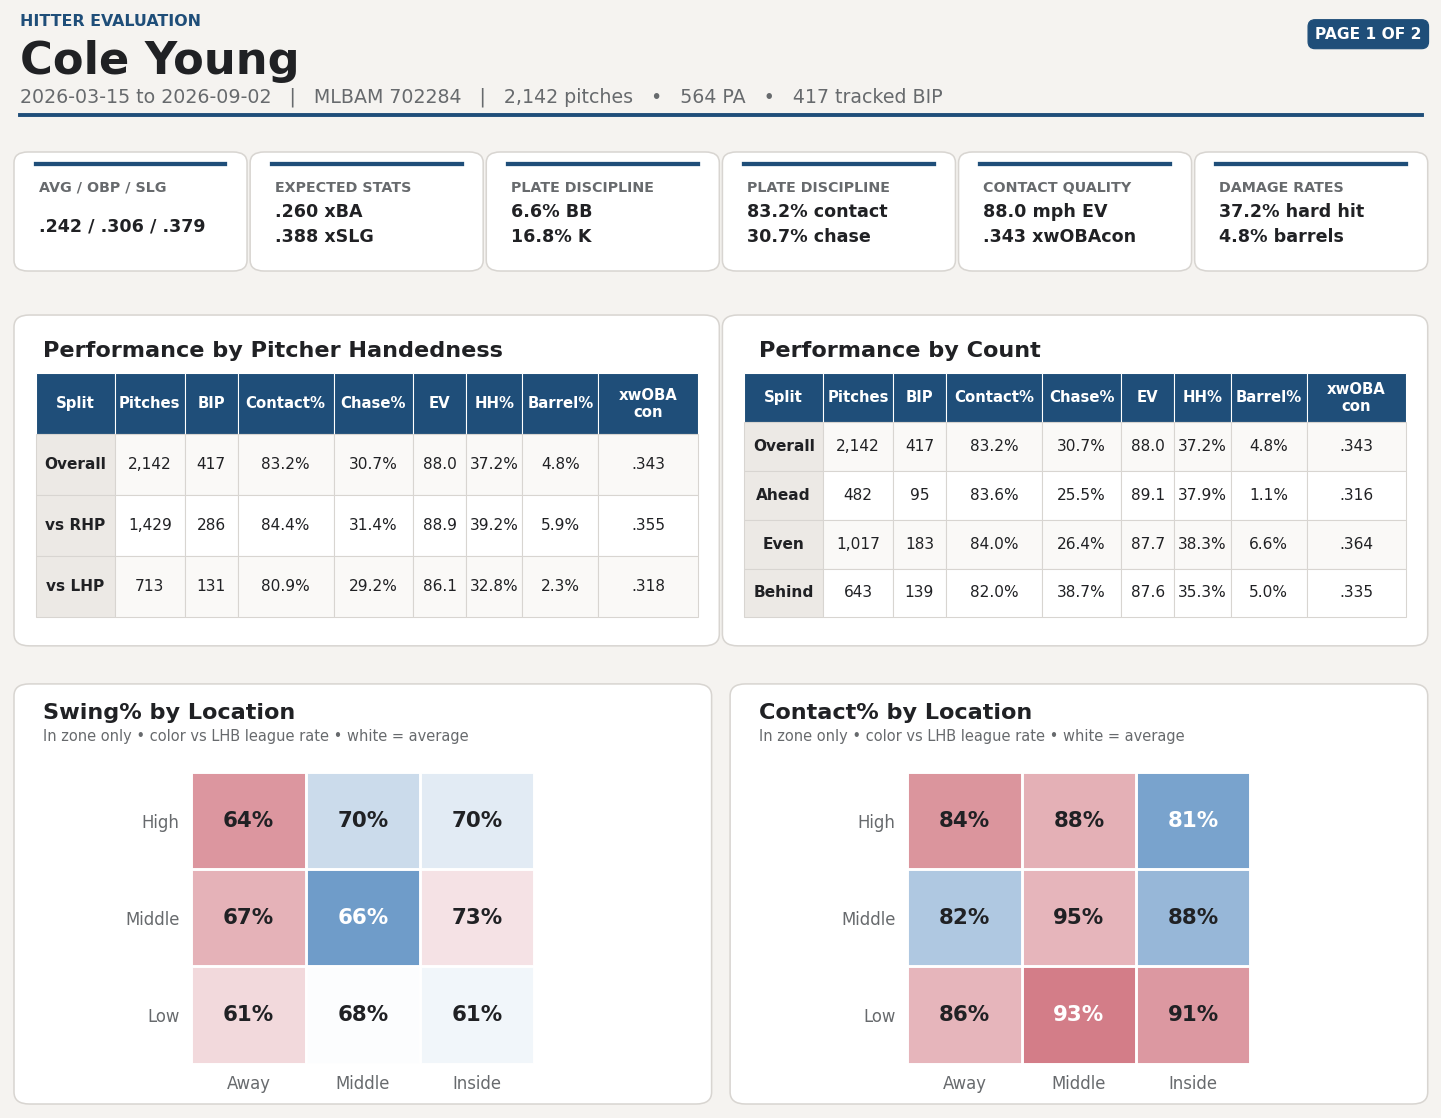

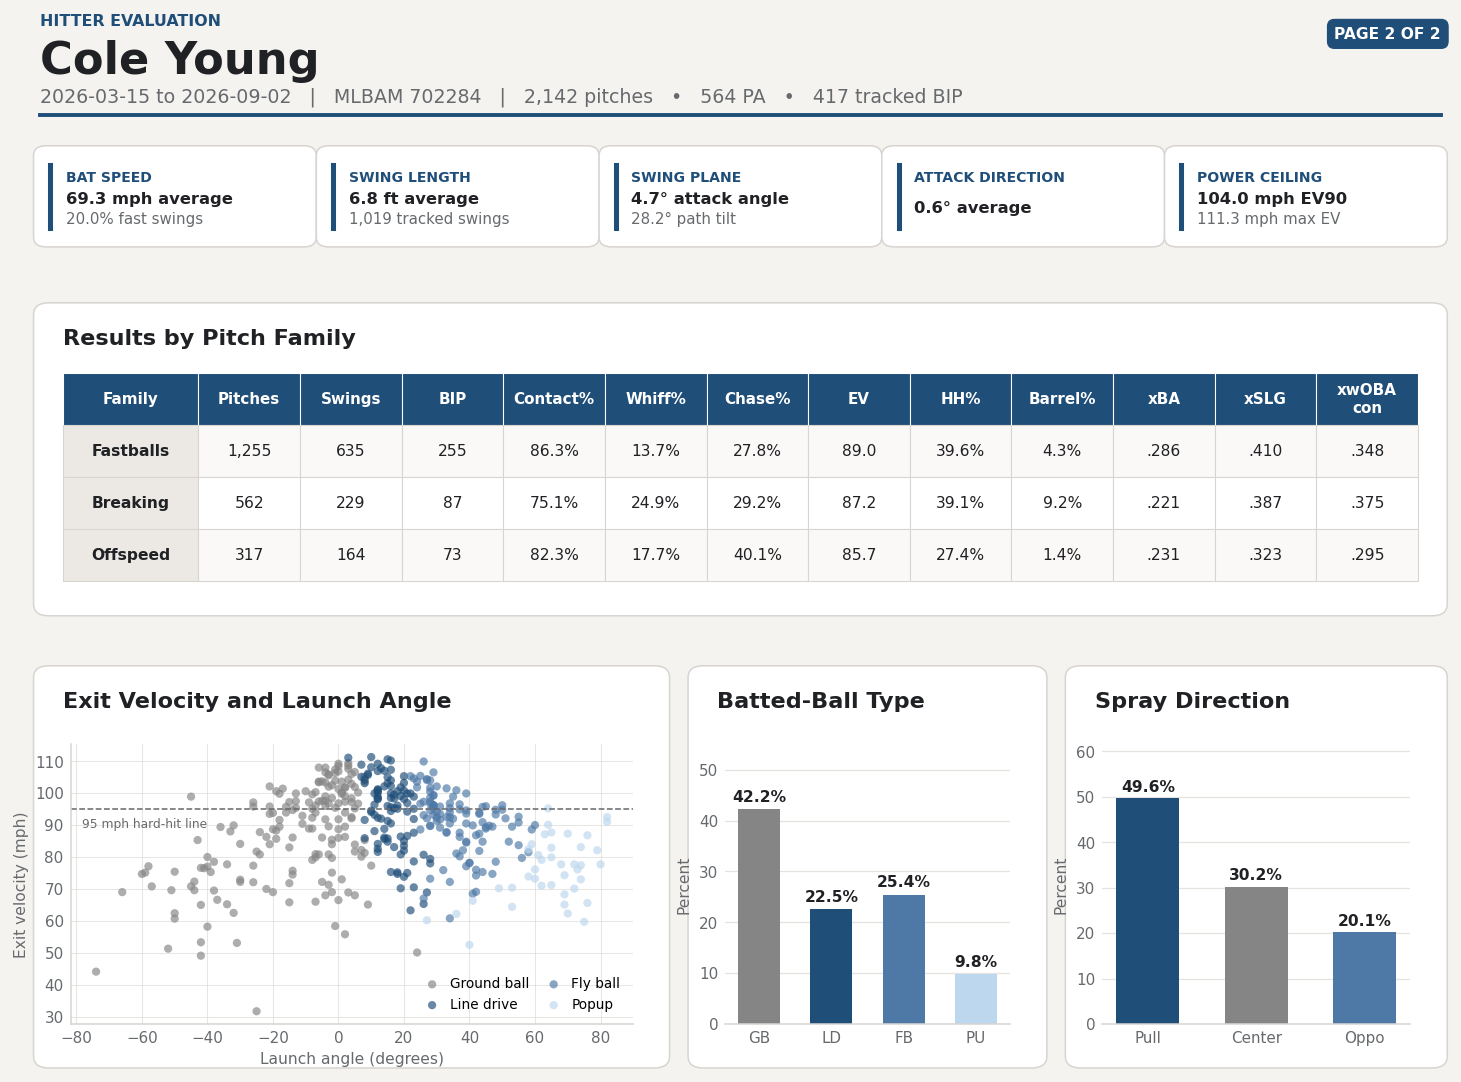

Report complete
PDF: C:\Users\brend\Downloads\hitter_reports\cole_young_2026-3-15_2026-09-02_statcast_hitter_evaluation.pdf
Page 1 PNG: C:\Users\brend\Downloads\hitter_reports\cole_young_2026-3-15_2026-09-02_statcast_hitter_evaluation_page_1.png
Page 2 PNG: C:\Users\brend\Downloads\hitter_reports\cole_young_2026-3-15_2026-09-02_statcast_hitter_evaluation_page_2.png
Tables: C:\Users\brend\Downloads\hitter_reports\cole_young_2026-3-15_2026-09-02_statcast_hitter_evaluation_tables.xlsx


In [ ]:
player_slug = slugify(PLAYER_NAME)
report_stem = f"{player_slug}_{START_DATE}_{END_DATE}_statcast_hitter_evaluation"
PDF_PATH = OUTPUT_DIR / f"{report_stem}.pdf"
PAGE_1_PATH = OUTPUT_DIR / f"{report_stem}_page_1.png"
PAGE_2_PATH = OUTPUT_DIR / f"{report_stem}_page_2.png"
TABLES_PATH = OUTPUT_DIR / f"{report_stem}_tables.xlsx"

page1, page2 = create_report_pages()
with PdfPages(PDF_PATH) as pdf:
    pdf.savefig(page1, facecolor="white")
    pdf.savefig(page2, facecolor="white")

page1.savefig(PAGE_1_PATH, dpi=REPORT_DPI, facecolor="white")
page2.savefig(PAGE_2_PATH, dpi=REPORT_DPI, facecolor="white")

with pd.ExcelWriter(TABLES_PATH, engine="openpyxl") as writer:
    overall.to_frame("Value").to_excel(writer, sheet_name="Overall")
    hand_splits.to_excel(writer, sheet_name="By Hand")
    count_splits.to_excel(writer, sheet_name="By Count")
    pitch_splits.to_excel(writer, sheet_name="By Pitch")

plt.show()

print("Report complete")
print(f"PDF: {PDF_PATH.resolve()}")
print(f"Page 1 PNG: {PAGE_1_PATH.resolve()}")
print(f"Page 2 PNG: {PAGE_2_PATH.resolve()}")
print(f"Tables: {TABLES_PATH.resolve()}")
